<a href="https://colab.research.google.com/github/Ammar-muz/NorthStar-Analytics/blob/main/NorthStar_SQL_R_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
install.packages("sqldf")
install.packages("ggplot2")
install.packages("dplyr")

library(sqldf)
library(ggplot2)
library(dplyr)

cat("All packages loaded successfully\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



All packages loaded successfully


In [ ]:
deliveries <- read.csv("deliveries.csv")
orders     <- read.csv("orders.csv")
complaints <- read.csv("complaints.csv")
customers  <- read.csv("customers.csv")
drivers    <- read.csv("drivers.csv")
vehicles   <- read.csv("vehicles.csv")
incidents  <- read.csv("incidents.csv")
hubs       <- read.csv("hubs.csv")
app_events <- read.csv("app_events.csv")

cat("=== Dataset Summary ===\n")
cat("Deliveries:", nrow(deliveries), "rows |",
    ncol(deliveries), "columns\n")
cat("Orders:    ", nrow(orders),     "rows |",
    ncol(orders),     "columns\n")
cat("Complaints:", nrow(complaints), "rows |",
    ncol(complaints), "columns\n")
cat("Customers: ", nrow(customers),  "rows |",
    ncol(customers),  "columns\n")
cat("Drivers:   ", nrow(drivers),    "rows |",
    ncol(drivers),    "columns\n")
cat("Vehicles:  ", nrow(vehicles),   "rows |",
    ncol(vehicles),   "columns\n")
cat("Incidents: ", nrow(incidents),  "rows |",
    ncol(incidents),  "columns\n")
cat("Hubs:      ", nrow(hubs),       "rows |",
    ncol(hubs),       "columns\n")
cat("App Events:", nrow(app_events), "rows |",
    ncol(app_events), "columns\n")

=== Dataset Summary ===
Deliveries: 950 rows | 13 columns
Orders:     1250 rows | 11 columns
Complaints: 320 rows | 10 columns
Customers:  650 rows | 9 columns
Drivers:    170 rows | 8 columns
Vehicles:   120 rows | 8 columns
Incidents:  280 rows | 7 columns
Hubs:       8 rows | 5 columns
App Events: 640 rows | 10 columns


  delivery_status total avg_cost avg_distance_km avg_rating avg_overrides
1          OnTime   616    12.68           13.78       4.28          0.92
2         Delayed   202    13.14           14.67       3.11          1.07
3          Failed   132    13.15           13.37       3.05          1.04


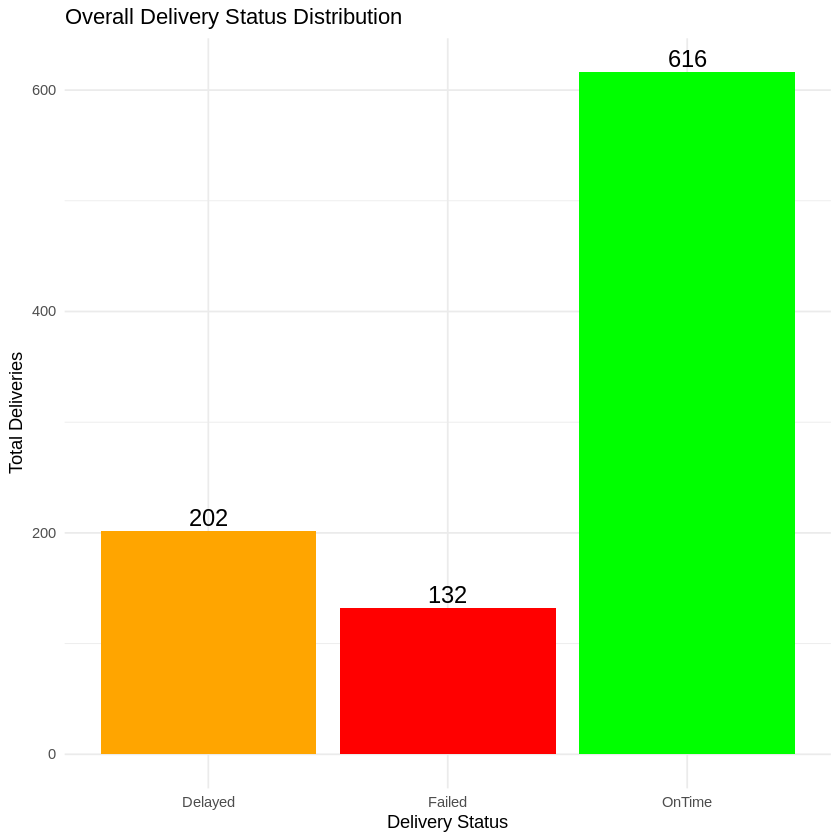

In [ ]:
q1 <- sqldf("
  SELECT delivery_status,
         COUNT(*) AS total,
         ROUND(AVG(fuel_or_charge_cost), 2)           AS avg_cost,
         ROUND(AVG(route_distance_km), 2)             AS avg_distance_km,
         ROUND(AVG(customer_rating_post_delivery), 2) AS avg_rating,
         ROUND(AVG(manual_route_override_count), 2)   AS avg_overrides
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY total DESC
")

print(q1)

ggplot(q1, aes(x=delivery_status, y=total, fill=delivery_status)) +
  geom_bar(stat="identity") +
  geom_text(aes(label=total), vjust=-0.3, size=5) +
  scale_fill_manual(values=c(
    "OnTime"="green","Delayed"="orange","Failed"="red")) +
  labs(title="Overall Delivery Status Distribution",
       x="Delivery Status", y="Total Deliveries") +
  theme_minimal() +
  theme(legend.position="none")

  hub_id       hub_name      zone  hub_type capacity_score total_deliveries
1    H08  Midtown Relay   Central  Charging             63              128
2    H05   Central Core   Central   Control             88              115
3    H01 North Exchange     North  Dispatch             82              136
4    H04      West Gate      West  Dispatch             69              127
5    H06    Airport Hub   Airport  Dispatch             71              104
6    H07  Riverside Hub Riverside Warehouse             66              115
7    H03      East Dock      East Warehouse             74              119
8    H02     South Link     South  Dispatch             78              106
  failed delayed avg_cost avg_rating
1     26      22    11.71       3.88
2     23      25    13.69       3.67
3     17      26    12.76       3.84
4     16      28    13.17       3.92
5     15      27    13.32       3.88
6     14      25    12.92       3.88
7     11      23    12.74       3.90
8     10      26    

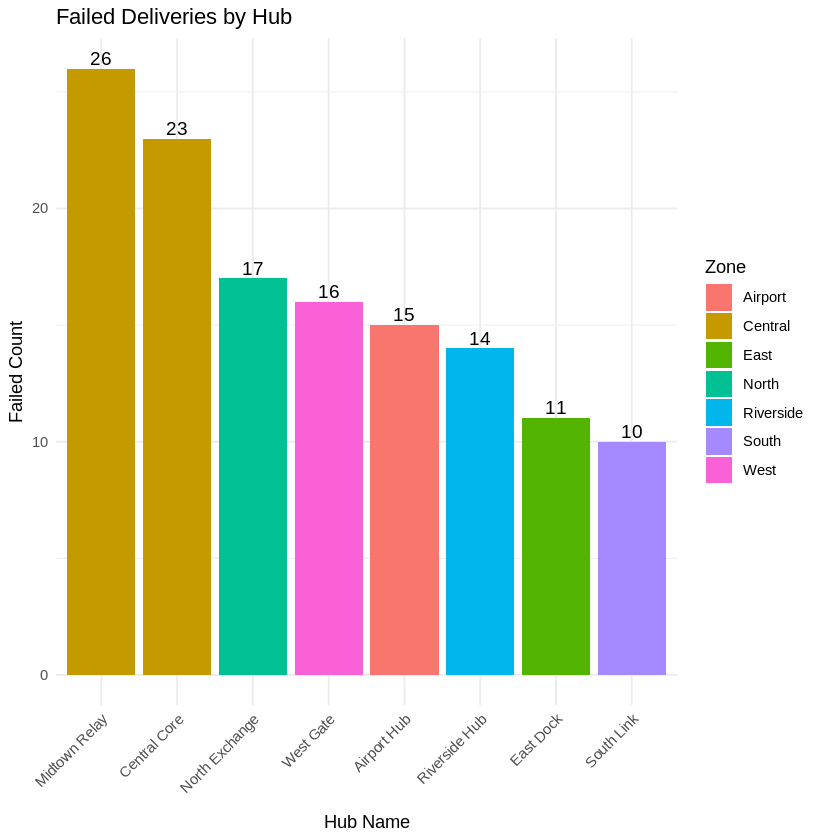

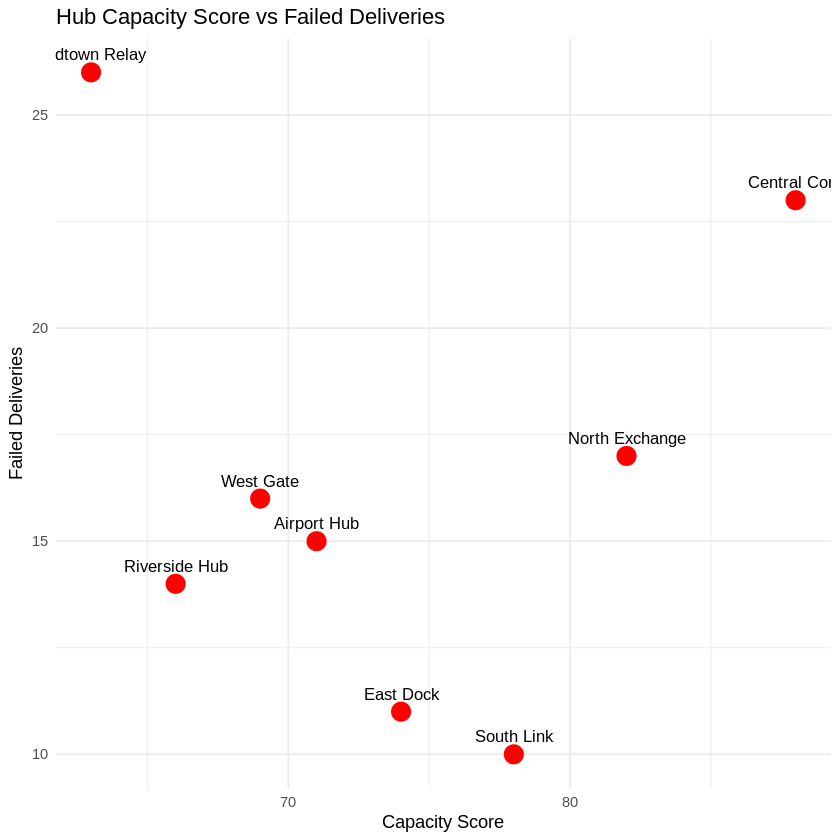

In [ ]:
q2 <- sqldf("
  SELECT h.hub_id,
         h.hub_name,
         h.zone,
         h.hub_type,
         h.capacity_score,
         COUNT(*) AS total_deliveries,
         SUM(CASE WHEN d.delivery_status='Failed'  THEN 1 ELSE 0 END) AS failed,
         SUM(CASE WHEN d.delivery_status='Delayed' THEN 1 ELSE 0 END) AS delayed,
         ROUND(AVG(d.fuel_or_charge_cost), 2)           AS avg_cost,
         ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating
  FROM hubs h
  JOIN deliveries d ON h.hub_id = d.hub_id
  GROUP BY h.hub_id, h.hub_name, h.zone,
           h.hub_type, h.capacity_score
  ORDER BY failed DESC
")

print(q2)

ggplot(q2, aes(x=reorder(hub_name, -failed), y=failed, fill=zone)) +
  geom_bar(stat="identity") +
  geom_text(aes(label=failed), vjust=-0.3, size=4) +
  labs(title="Failed Deliveries by Hub",
       x="Hub Name", y="Failed Count", fill="Zone") +
  theme_minimal() +
  theme(axis.text.x=element_text(angle=45, hjust=1))

ggplot(q2, aes(x=capacity_score, y=failed, label=hub_name)) +
  geom_point(size=5, color="red") +
  geom_text(vjust=-1, size=3.5) +
  labs(title="Hub Capacity Score vs Failed Deliveries",
       x="Capacity Score", y="Failed Deliveries") +
  theme_minimal()

   pickup_zone total failed delayed avg_distance
1    RiverSide    66     14      12        12.32
2         EAST    78     11      14        12.95
3          Ctr    64     11      24        11.57
4      Central    55     11      11        11.58
5      CENTRAL    55     11      16        12.61
6        South    83     10      15        12.32
7        north    52      8       6        12.18
8         East    78      8      17        11.15
9      Airport    67      8      18        28.91
10        West    51      7       8        13.79


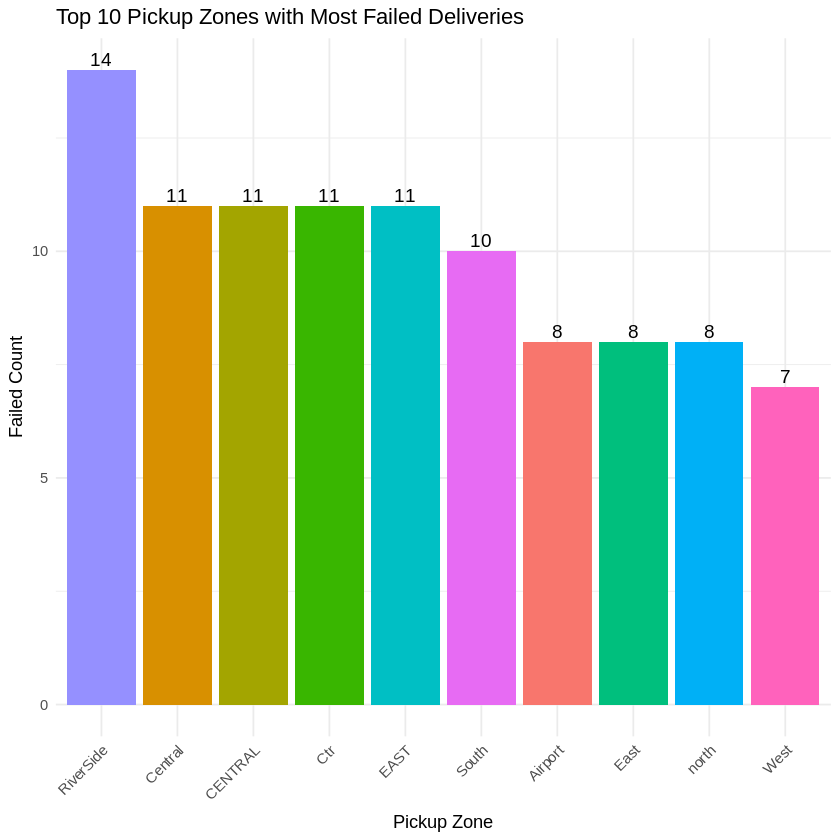

In [ ]:
q3 <- sqldf("
  SELECT o.pickup_zone,
         COUNT(*) AS total,
         SUM(CASE WHEN d.delivery_status='Failed'  THEN 1 ELSE 0 END) AS failed,
         SUM(CASE WHEN d.delivery_status='Delayed' THEN 1 ELSE 0 END) AS delayed,
         ROUND(AVG(d.route_distance_km), 2) AS avg_distance
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.pickup_zone
  ORDER BY failed DESC
  LIMIT 10
")

print(q3)

ggplot(q3, aes(x=reorder(pickup_zone, -failed),
               y=failed, fill=pickup_zone)) +
  geom_bar(stat="identity") +
  geom_text(aes(label=failed), vjust=-0.3, size=4) +
  labs(title="Top 10 Pickup Zones with Most Failed Deliveries",
       x="Pickup Zone", y="Failed Count") +
  theme_minimal() +
  theme(axis.text.x=element_text(angle=45, hjust=1),
        legend.position="none")

   service_type booking_channel total failed delayed avg_cost avg_rating
1     Passenger             App   127     24      30    12.10       3.69
2        Parcel             App   129     15      27    13.14       3.87
3        Retail             App   122     14      28    13.26       3.83
4      Business             App    75     12      18    12.99       3.91
5      Business             Web    23      8       3    12.99       3.51
6        Retail           Phone    50      8      13    12.05       3.90
7     Passenger           Phone    56      7       6    12.82       4.07
8       Medical             Web    30      6       5    11.77       3.67
9        Parcel           Phone    41      6       7    13.26       3.95
10    Passenger             Web    64      6      15    12.56       3.87
11     Business           Phone    23      5       6    14.28       3.86
12      Medical             App    52      5      15    13.03       3.96
13      Medical           Phone    17      3       

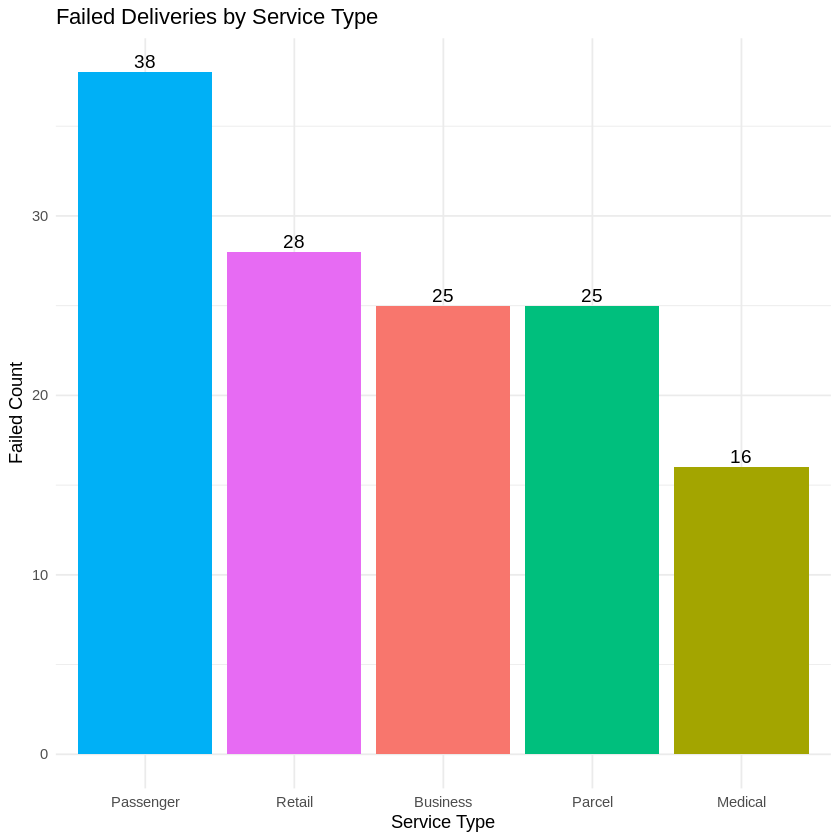

In [ ]:
q4 <- sqldf("
  SELECT o.service_type,
         o.booking_channel,
         COUNT(*) AS total,
         SUM(CASE WHEN d.delivery_status='Failed'  THEN 1 ELSE 0 END) AS failed,
         SUM(CASE WHEN d.delivery_status='Delayed' THEN 1 ELSE 0 END) AS delayed,
         ROUND(AVG(d.fuel_or_charge_cost), 2)           AS avg_cost,
         ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating,
         ROUND(AVG(o.order_value), 2)                   AS avg_order_value
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.service_type, o.booking_channel
  ORDER BY failed DESC
")

print(q4)

service_summary <- sqldf("
  SELECT o.service_type,
         COUNT(*) AS total,
         SUM(CASE WHEN d.delivery_status='Failed' THEN 1 ELSE 0 END) AS failed,
         ROUND(AVG(d.customer_rating_post_delivery),2) AS avg_rating
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.service_type
  ORDER BY failed DESC
")

ggplot(service_summary, aes(x=reorder(service_type,-failed),
                            y=failed, fill=service_type)) +
  geom_bar(stat="identity") +
  geom_text(aes(label=failed), vjust=-0.3, size=4) +
  labs(title="Failed Deliveries by Service Type",
       x="Service Type", y="Failed Count") +
  theme_minimal() +
  theme(legend.position="none")

  priority_level total failed delayed avg_distance avg_cost
1         Medium   386     63      88        13.97    13.20
2            Low   259     34      53        14.36    12.85
3           High   231     32      46        13.69    12.71
4       Critical    74      3      15        12.66    11.32


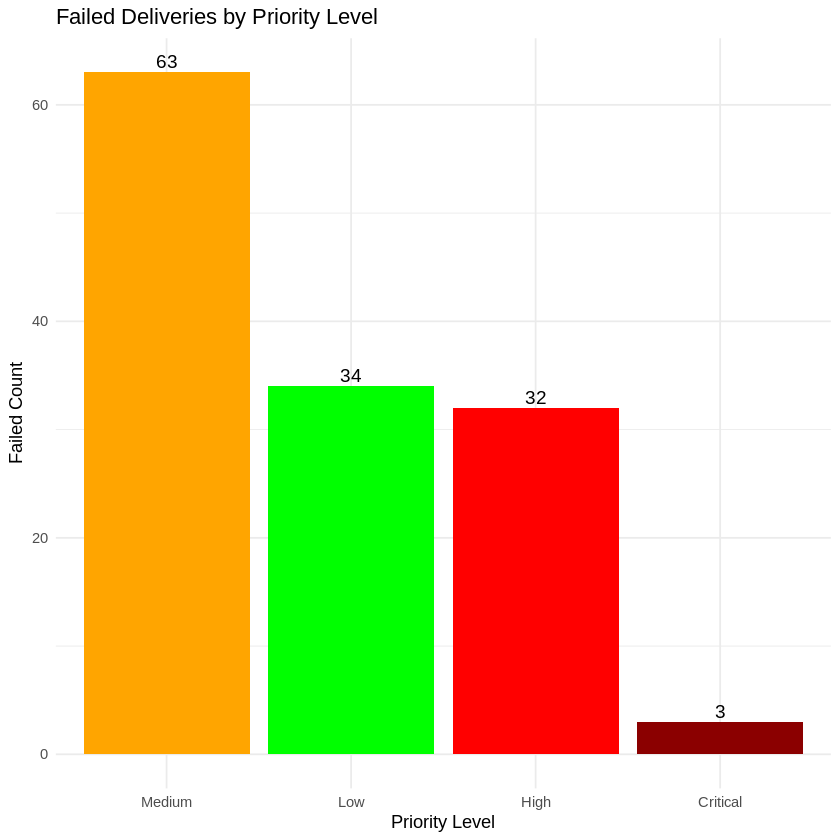

In [ ]:
q5 <- sqldf("
  SELECT o.priority_level,
         COUNT(*) AS total,
         SUM(CASE WHEN d.delivery_status='Failed'  THEN 1 ELSE 0 END) AS failed,
         SUM(CASE WHEN d.delivery_status='Delayed' THEN 1 ELSE 0 END) AS delayed,
         ROUND(AVG(d.route_distance_km), 2)  AS avg_distance,
         ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_cost
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.priority_level
  ORDER BY failed DESC
")

print(q5)

ggplot(q5, aes(x=reorder(priority_level, -failed),
               y=failed, fill=priority_level)) +
  geom_bar(stat="identity") +
  geom_text(aes(label=failed), vjust=-0.3, size=4) +
  scale_fill_manual(values=c(
    "Critical"="darkred","High"="red",
    "Medium"="orange","Low"="green")) +
  labs(title="Failed Deliveries by Priority Level",
       x="Priority Level", y="Failed Count") +
  theme_minimal() +
  theme(legend.position="none")

   driver_id employment_type years_experience training_score driver_rating
1       D026        PartTime                4           84.9          3.15
2       D053        FullTime                5           83.3          3.80
3       D100        FullTime                4           62.0          4.31
4       D141        PartTime               14           71.4          3.44
5       D028        FullTime               11           83.0          4.07
6       D031        FullTime               10           91.5          4.03
7       D050        FullTime                6           87.4          3.90
8       D074        FullTime               12           79.5          4.61
9       D077        FullTime                8           64.9          3.68
10      D094        PartTime                6           60.8          4.48
   base_zone total_deliveries delayed failed
1      NORTH               11       4      0
2       West                7       4      1
3    CENTRAL                8       4   

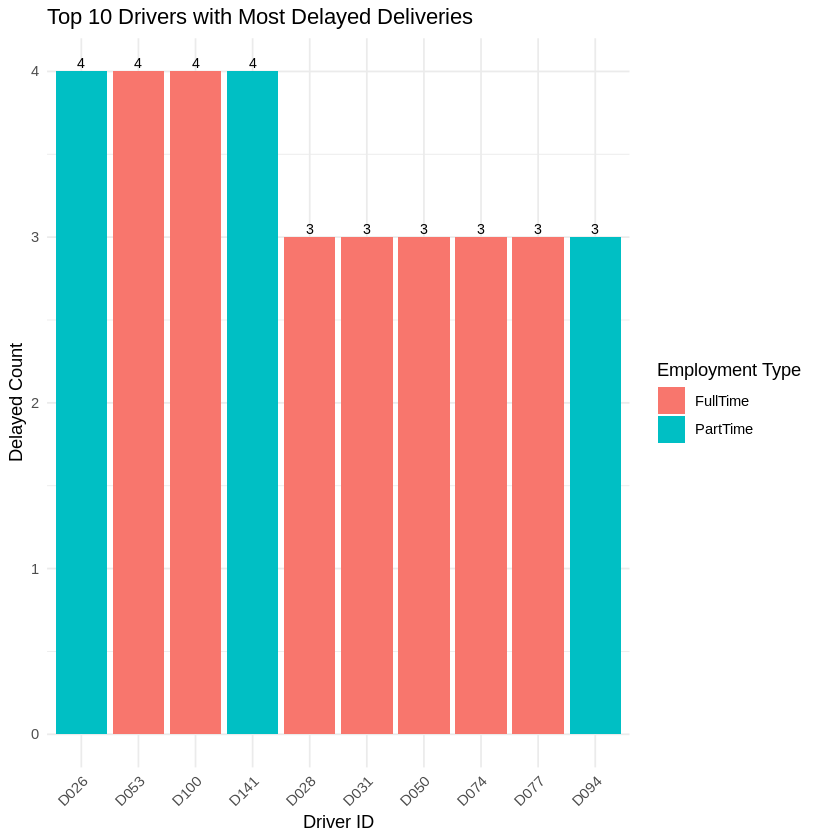

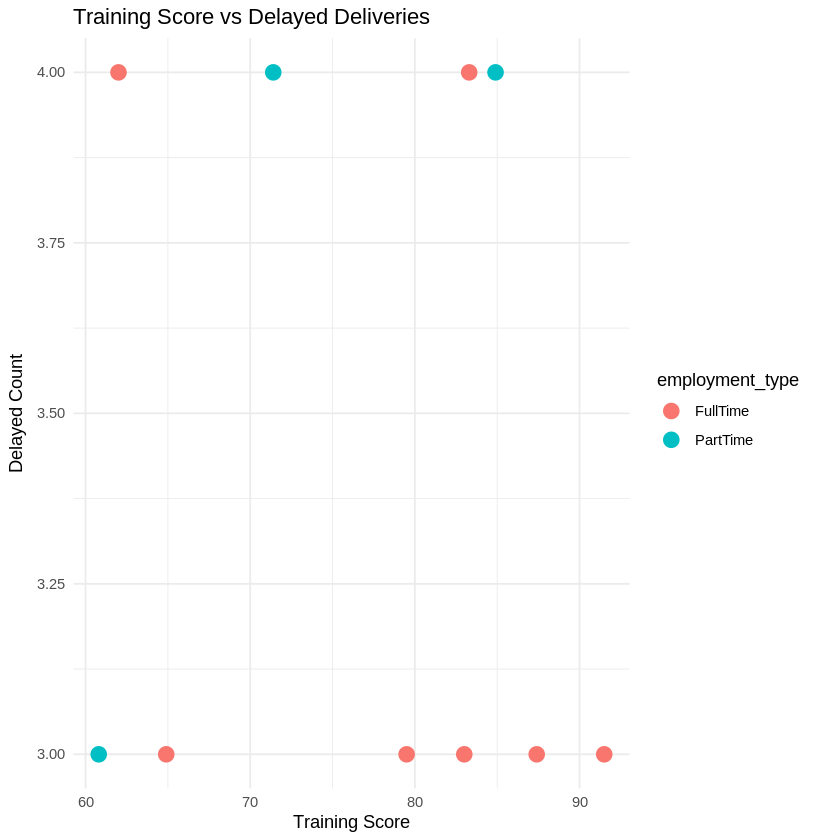

In [ ]:
q6 <- sqldf("
  SELECT d.driver_id,
         dr.employment_type,
         dr.years_experience,
         dr.training_score,
         dr.driver_rating,
         dr.base_zone,
         COUNT(*) AS total_deliveries,
         SUM(CASE WHEN d.delivery_status='Delayed' THEN 1 ELSE 0 END) AS delayed,
         SUM(CASE WHEN d.delivery_status='Failed'  THEN 1 ELSE 0 END) AS failed
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY d.driver_id, dr.employment_type, dr.years_experience,
           dr.training_score, dr.driver_rating, dr.base_zone
  ORDER BY delayed DESC
  LIMIT 10
")

print(q6)

ggplot(q6, aes(x=reorder(driver_id,-delayed),
               y=delayed, fill=employment_type)) +
  geom_bar(stat="identity") +
  geom_text(aes(label=delayed), vjust=-0.3, size=3) +
  labs(title="Top 10 Drivers with Most Delayed Deliveries",
       x="Driver ID", y="Delayed Count",
       fill="Employment Type") +
  theme_minimal() +
  theme(axis.text.x=element_text(angle=45, hjust=1))

ggplot(q6, aes(x=training_score, y=delayed, color=employment_type)) +
  geom_point(size=4) +
  labs(title="Training Score vs Delayed Deliveries",
       x="Training Score", y="Delayed Count") +
  theme_minimal()

   maintenance_status vehicle_type total failed delayed avg_battery
1            InRepair     CargoVan    68     22      16       69.82
2            InRepair       Hybrid    71     21      11       83.27
3            InRepair       Diesel    55     17      11       75.65
4            InRepair           EV    60     17      14       77.79
5              Active       Hybrid   131     15      25       73.67
6              Active     CargoVan   117     11      29       74.41
7              Active           EV   214     11      48       83.00
8              Active       Diesel    80      8      11       67.02
9           Scheduled     CargoVan    38      5       8       68.96
10          Scheduled           EV    65      2      12       82.92
11          Scheduled       Hybrid    42      2      16       80.56
12          Scheduled       Diesel     9      1       1       81.33
   avg_odometer
1     104131.01
2     130176.85
3      93865.76
4     148940.78
5     120494.78
6     102701.86
7   

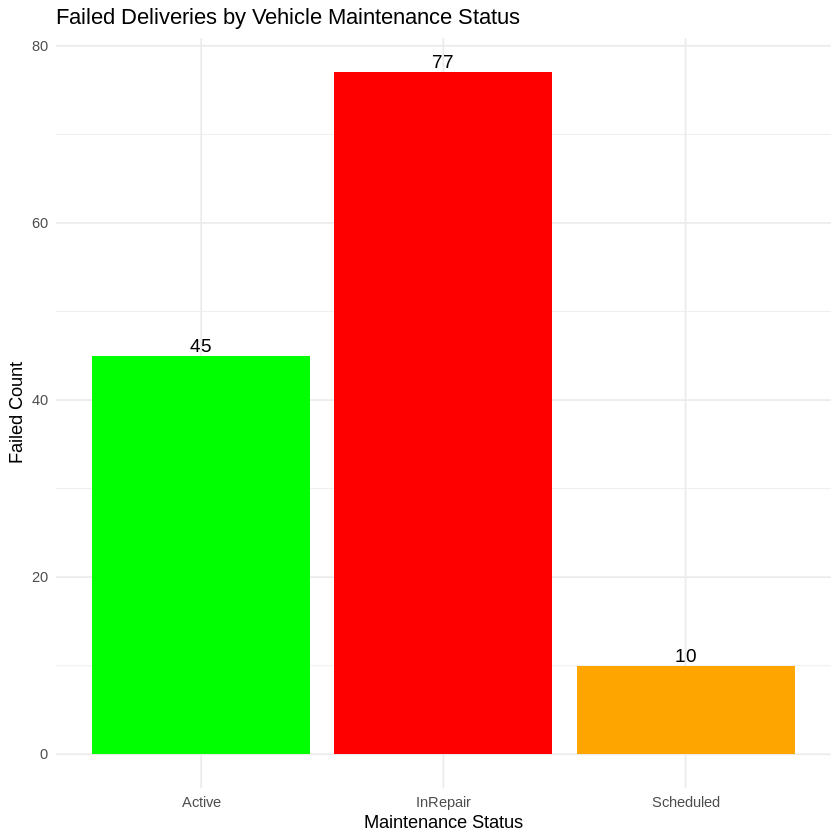

In [ ]:
q7 <- sqldf("
  SELECT v.maintenance_status,
         v.vehicle_type,
         COUNT(*) AS total,
         SUM(CASE WHEN d.delivery_status='Failed'  THEN 1 ELSE 0 END) AS failed,
         SUM(CASE WHEN d.delivery_status='Delayed' THEN 1 ELSE 0 END) AS delayed,
         ROUND(AVG(v.battery_health_pct), 2) AS avg_battery,
         ROUND(AVG(v.odometer_km), 2)        AS avg_odometer
  FROM deliveries d
  JOIN vehicles v ON d.vehicle_id = v.vehicle_id
  GROUP BY v.maintenance_status, v.vehicle_type
  ORDER BY failed DESC
")

print(q7)

maint_summary <- sqldf("
  SELECT v.maintenance_status,
         COUNT(*) AS total,
         SUM(CASE WHEN d.delivery_status='Failed' THEN 1 ELSE 0 END) AS failed,
         ROUND(AVG(v.battery_health_pct),2) AS avg_battery
  FROM deliveries d
  JOIN vehicles v ON d.vehicle_id = v.vehicle_id
  GROUP BY v.maintenance_status
")

ggplot(maint_summary, aes(x=maintenance_status,
                          y=failed, fill=maintenance_status)) +
  geom_bar(stat="identity") +
  geom_text(aes(label=failed), vjust=-0.3, size=4) +
  scale_fill_manual(values=c(
    "Active"="green","InRepair"="red","Scheduled"="orange")) +
  labs(title="Failed Deliveries by Vehicle Maintenance Status",
       x="Maintenance Status", y="Failed Count") +
  theme_minimal() +
  theme(legend.position="none")

    complaint_type severity           status customer_type total
1            Delay   Medium         Resolved      Consumer    21
2            Delay      Low         Resolved      Consumer    15
3     MissedPickup   Medium         Resolved      Consumer    15
4  DriverBehaviour   Medium         Resolved      Consumer    14
5         AppIssue   Medium         Resolved      Consumer    13
6     MissedPickup     High         Resolved      Consumer    12
7            Delay   Medium AwaitingCustomer      Consumer    11
8            Delay   Medium             Open      Consumer     8
9  DriverBehaviour     High         Resolved      Consumer     8
10        AppIssue     High         Resolved           SME     5
11        AppIssue      Low         Resolved      Consumer     5
12           Delay      Low         Resolved           SME     5
13           Delay   Medium        Escalated      Consumer     5
14           Delay   Medium         Resolved           SME     5
15    MissedPickup   Medi

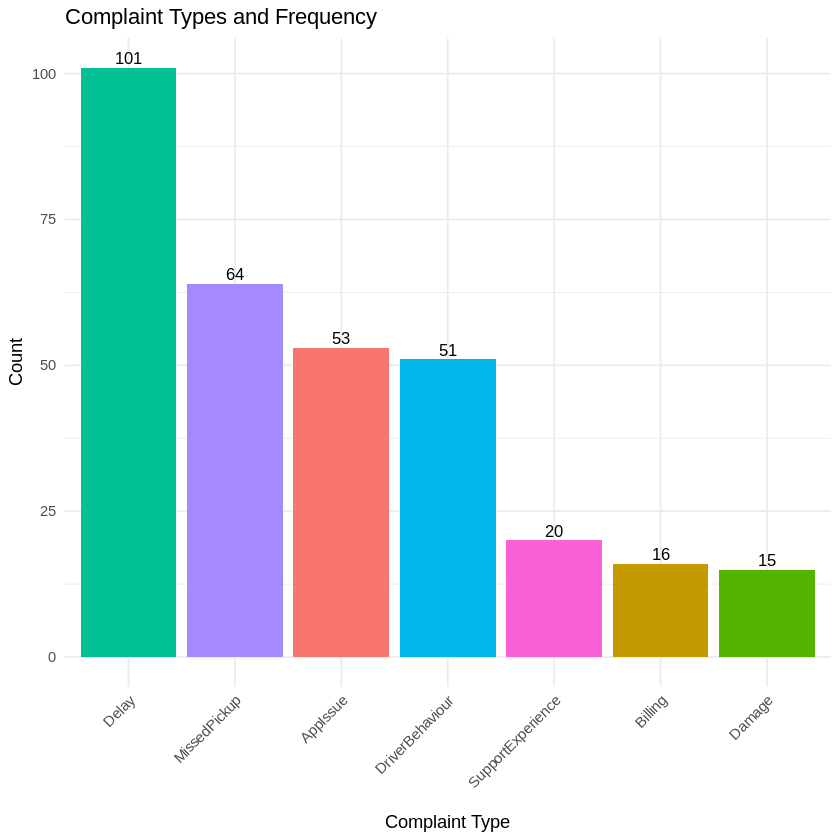

In [ ]:
q8 <- sqldf("
  SELECT c.complaint_type,
         c.severity,
         c.status,
         cu.customer_type,
         COUNT(*) AS total,
         ROUND(AVG(c.resolution_days), 2)    AS avg_resolution_days,
         ROUND(AVG(c.compensation_amount), 2) AS avg_compensation
  FROM complaints c
  JOIN customers cu ON c.customer_id = cu.customer_id
  GROUP BY c.complaint_type, c.severity,
           c.status, cu.customer_type
  ORDER BY total DESC
  LIMIT 15
")

print(q8)

complaint_type_summary <- sqldf("
  SELECT complaint_type,
         COUNT(*) AS total,
         ROUND(AVG(resolution_days),2) AS avg_days
  FROM complaints
  GROUP BY complaint_type
  ORDER BY total DESC
")

ggplot(complaint_type_summary,
       aes(x=reorder(complaint_type,-total),
           y=total, fill=complaint_type)) +
  geom_bar(stat="identity") +
  geom_text(aes(label=total), vjust=-0.3, size=3.5) +
  labs(title="Complaint Types and Frequency",
       x="Complaint Type", y="Count") +
  theme_minimal() +
  theme(axis.text.x=element_text(angle=45, hjust=1),
        legend.position="none")

   severity    complaint_type delivery_status hub_id customer_type
1    Medium      MissedPickup          OnTime    H03      Consumer
2    Medium             Delay          OnTime    H06      Consumer
3    Medium             Delay          OnTime    H08      Consumer
4    Medium             Delay          OnTime    H01      Consumer
5    Medium             Delay          OnTime    H05      Consumer
6    Medium   DriverBehaviour          OnTime    H06      Consumer
7    Medium   DriverBehaviour          OnTime    H08      Consumer
8    Medium SupportExperience          OnTime    H05      Consumer
9      High             Delay         Delayed    H03      Consumer
10     High   DriverBehaviour          OnTime    H06      Consumer
11     High   DriverBehaviour          OnTime    H08      Consumer
12     High      MissedPickup          OnTime    H07      Consumer
13     High      MissedPickup          OnTime    H08      Consumer
14      Low          AppIssue          OnTime    H06      Cons

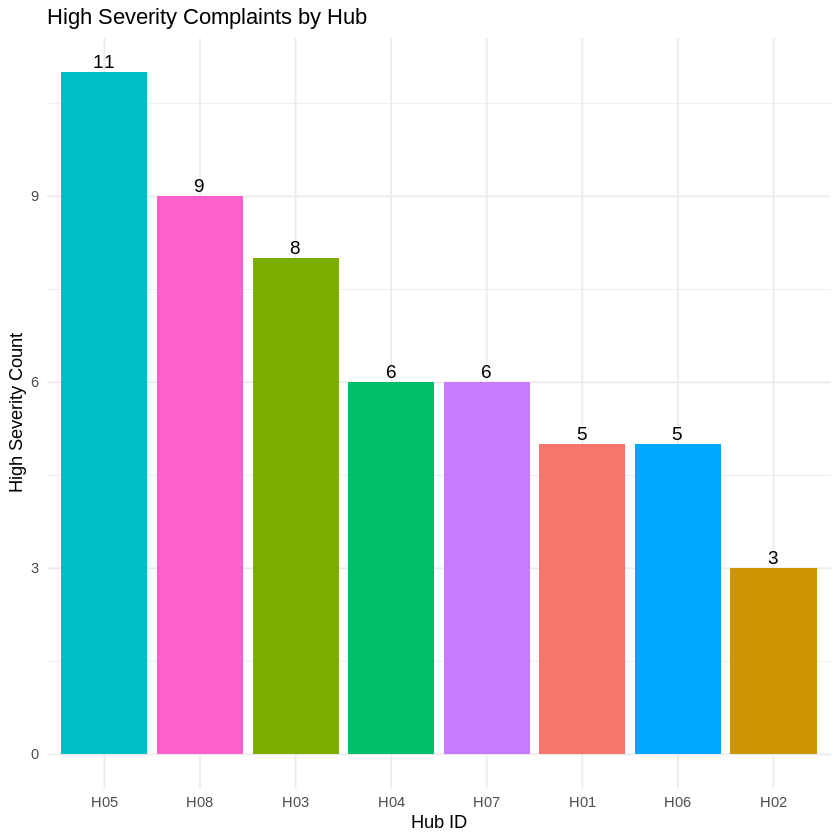

In [ ]:
q9 <- sqldf("
  SELECT c.severity,
         c.complaint_type,
         d.delivery_status,
         d.hub_id,
         cu.customer_type,
         cu.account_status,
         COUNT(*) AS count,
         ROUND(AVG(c.compensation_amount),2) AS avg_compensation
  FROM complaints c
  JOIN deliveries d  ON c.order_id    = d.order_id
  JOIN customers  cu ON c.customer_id = cu.customer_id
  GROUP BY c.severity, c.complaint_type,
           d.delivery_status, d.hub_id,
           cu.customer_type, cu.account_status
  ORDER BY count DESC
  LIMIT 15
")

print(q9)

hub_high <- sqldf("
  SELECT d.hub_id,
         COUNT(*) AS high_severity_count
  FROM complaints c
  JOIN deliveries d ON c.order_id = d.order_id
  WHERE c.severity = 'High'
  GROUP BY d.hub_id
  ORDER BY high_severity_count DESC
")

print(hub_high)

ggplot(hub_high, aes(x=reorder(hub_id,-high_severity_count),
                     y=high_severity_count, fill=hub_id)) +
  geom_bar(stat="identity") +
  geom_text(aes(label=high_severity_count), vjust=-0.3, size=4) +
  labs(title="High Severity Complaints by Hub",
       x="Hub ID", y="High Severity Count") +
  theme_minimal() +
  theme(legend.position="none")

   customer_type employment_type delivery_status severity count avg_resolution
1       Consumer        FullTime          OnTime   Medium    41           6.66
2       Consumer        PartTime          OnTime   Medium    16           6.06
3       Consumer        FullTime         Delayed   Medium    15           5.00
4       Consumer        FullTime          OnTime     High    15          12.53
5       Consumer        FullTime          OnTime      Low    15           8.00
6       Consumer        Contract          OnTime   Medium    11           5.73
7       Consumer        PartTime          OnTime      Low     9           5.11
8       Consumer        FullTime          Failed   Medium     8           6.75
9            SME        FullTime          OnTime   Medium     7           5.71
10      Consumer        FullTime         Delayed     High     6          13.50
11      Consumer        FullTime          Failed     High     6          16.50
12      Consumer        Contract         Delayed   M

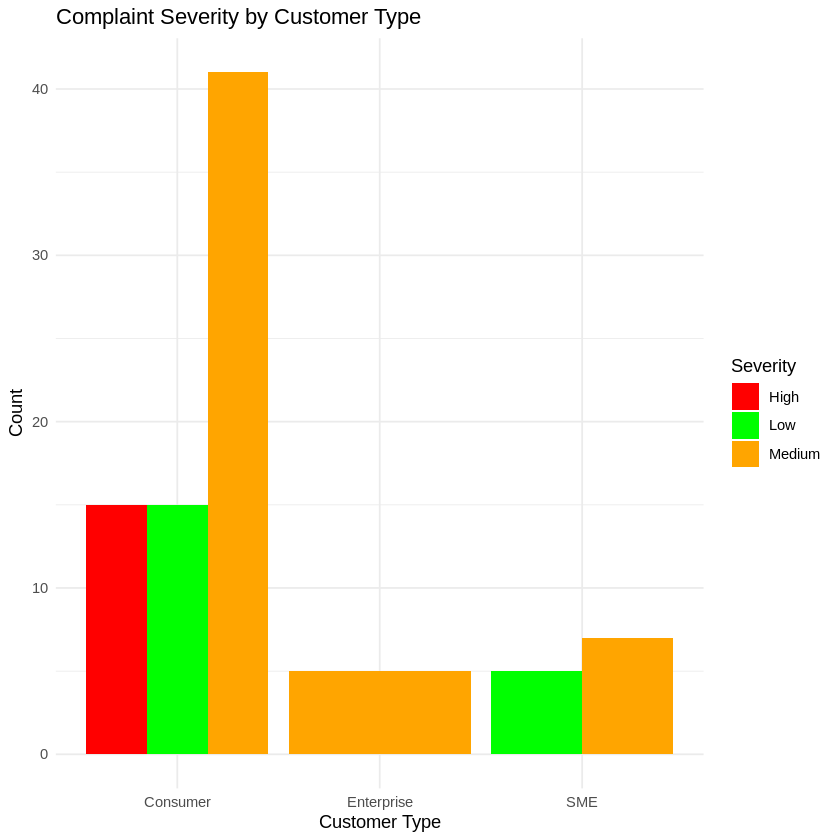

In [ ]:
q10 <- sqldf("
  SELECT cu.customer_type,
         dr.employment_type,
         d.delivery_status,
         c.severity,
         COUNT(*) AS count,
         ROUND(AVG(c.resolution_days),2)     AS avg_resolution,
         ROUND(AVG(dr.training_score),2)     AS avg_training,
         ROUND(AVG(dr.driver_rating),2)      AS avg_driver_rating
  FROM complaints c
  JOIN deliveries d  ON c.order_id    = d.order_id
  JOIN customers  cu ON c.customer_id = cu.customer_id
  JOIN drivers    dr ON d.driver_id   = dr.driver_id
  GROUP BY cu.customer_type, dr.employment_type,
           d.delivery_status, c.severity
  ORDER BY count DESC
  LIMIT 15
")

print(q10)

ggplot(q10, aes(x=customer_type, y=count, fill=severity)) +
  geom_bar(stat="identity", position="dodge") +
  scale_fill_manual(values=c(
    "High"="red","Medium"="orange","Low"="green")) +
  labs(title="Complaint Severity by Customer Type",
       x="Customer Type", y="Count", fill="Severity") +
  theme_minimal()

       incident_type severity resolution_status avg_resolved_hours total
1     CustomerNoShow   Medium            Closed              14.86    10
2       ProofMissing      Low            Closed              13.36    10
3     RouteDeviation      Low            Closed              17.05    10
4       AppSyncError   Medium     PendingVendor              14.29     8
5       BatteryAlert   Medium            Closed              11.26     7
6   TemperatureIssue   Medium            Closed              15.76     7
7       BatteryAlert   Medium              Open               9.70     6
8     CustomerNoShow      Low              Open              15.47     6
9       ProofMissing   Medium            Closed              10.38     6
10    RouteDeviation     High              Open              15.40     6
11      VehicleFault   Medium            Closed               2.20     6
12      VehicleFault   Medium              Open               8.47     6
13      BatteryAlert      Low            Closed    

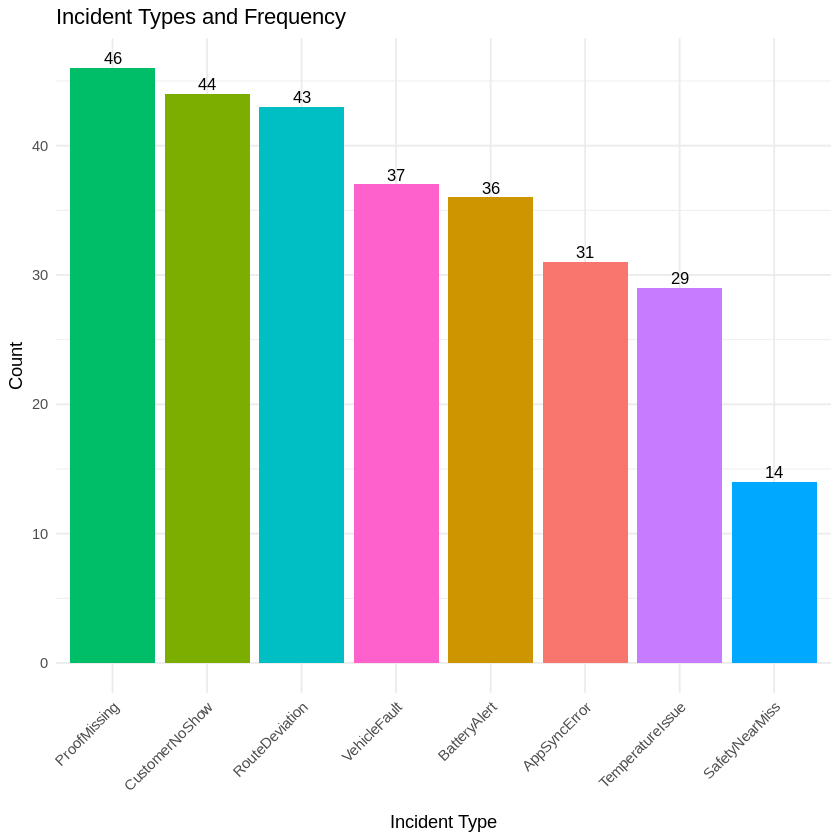

In [ ]:
q11 <- sqldf("
  SELECT i.incident_type,
         i.severity,
         i.resolution_status,
         ROUND(AVG(i.resolved_hours),2) AS avg_resolved_hours,
         COUNT(*) AS total,
         SUM(CASE WHEN d.delivery_status='Failed' THEN 1 ELSE 0 END) AS linked_failures
  FROM incidents i
  JOIN deliveries d ON i.delivery_id = d.delivery_id
  GROUP BY i.incident_type, i.severity, i.resolution_status
  ORDER BY total DESC
")

print(q11)

incident_summary <- sqldf("
  SELECT incident_type, COUNT(*) AS total
  FROM incidents
  GROUP BY incident_type
  ORDER BY total DESC
")

ggplot(incident_summary,
       aes(x=reorder(incident_type,-total),
           y=total, fill=incident_type)) +
  geom_bar(stat="identity") +
  geom_text(aes(label=total), vjust=-0.3, size=3.5) +
  labs(title="Incident Types and Frequency",
       x="Incident Type", y="Count") +
  theme_minimal() +
  theme(axis.text.x=element_text(angle=45, hjust=1),
        legend.position="none")

escalated <- sqldf("
  SELECT incident_type,
         resolution_status,
         COUNT(*) AS total
  FROM incidents
  WHERE resolution_status = 'Escalated'
  GROUP BY incident_type, resolution_status
  ORDER BY total DESC
")

print(escalated)

   customer_type account_status preferred_channel total_customers avg_loyalty
1       Consumer         Active               App             229       61.17
2       Consumer         Active               Web              90       59.07
3            SME         Active               App              61       57.51
4       Consumer         Active             Phone              59       58.34
5       Consumer        Dormant               App              30       59.26
6     Enterprise         Active               App              27       56.68
7            SME         Active               Web              21       52.15
8       Consumer         Active       Partner API              17       62.63
9            SME         Active             Phone              17       63.55
10      Consumer        Dormant             Phone              13       61.92
11      Consumer         Active                                11       64.15
12      Consumer        Dormant               Web              1

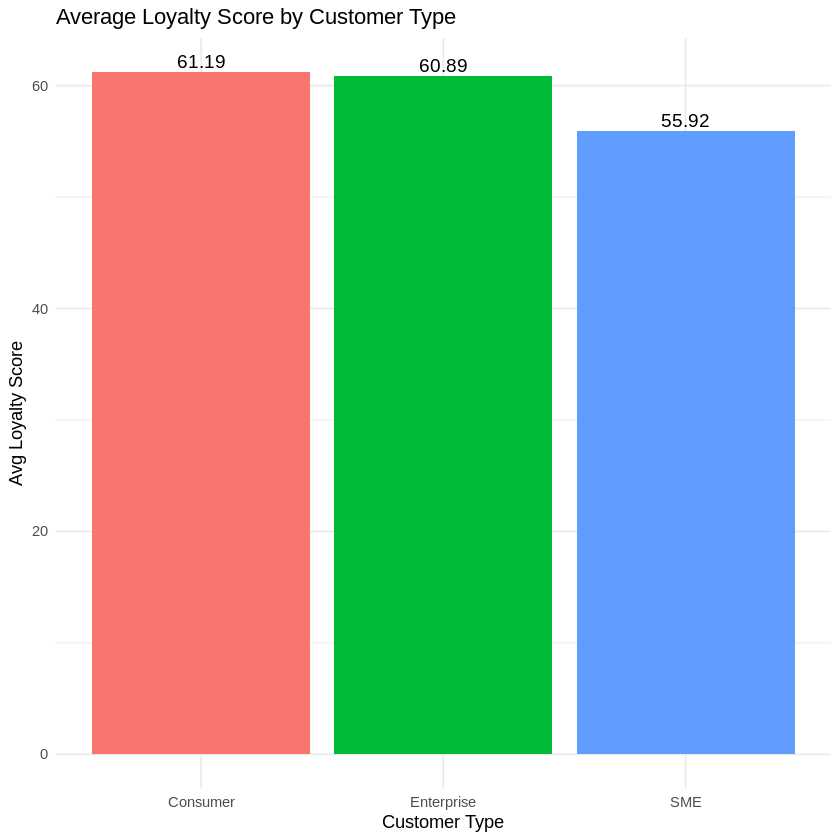

In [ ]:
q12 <- sqldf("
  SELECT cu.customer_type,
         cu.account_status,
         cu.preferred_channel,
         COUNT(DISTINCT cu.customer_id) AS total_customers,
         ROUND(AVG(cu.loyalty_score),2)       AS avg_loyalty,
         ROUND(AVG(cu.app_engagement_score),2) AS avg_engagement
  FROM customers cu
  GROUP BY cu.customer_type, cu.account_status, cu.preferred_channel
  ORDER BY total_customers DESC
  LIMIT 12
")

print(q12)

loyalty_complaint <- sqldf("
  SELECT cu.customer_type,
         COUNT(c.complaint_id) AS total_complaints,
         ROUND(AVG(cu.loyalty_score),2)        AS avg_loyalty,
         ROUND(AVG(c.compensation_amount),2)   AS avg_compensation,
         ROUND(AVG(c.resolution_days),2)       AS avg_resolution_days
  FROM customers cu
  JOIN complaints c ON cu.customer_id = c.customer_id
  GROUP BY cu.customer_type
  ORDER BY total_complaints DESC
")

print(loyalty_complaint)

ggplot(loyalty_complaint, aes(x=customer_type,
                              y=avg_loyalty, fill=customer_type)) +
  geom_bar(stat="identity") +
  geom_text(aes(label=avg_loyalty), vjust=-0.3, size=4) +
  labs(title="Average Loyalty Score by Customer Type",
       x="Customer Type", y="Avg Loyalty Score") +
  theme_minimal() +
  theme(legend.position="none")

                    event_type device_type total_events avg_latency
1                  track_order     Android           63      453.76
2                  eta_refresh     Android           54      460.63
3                 search_route     Android           50      450.40
4                  track_order         iOS           50      433.16
5                  chat_opened     Android           47      444.85
6                  chat_opened         iOS           37      535.38
7  delivery_instruction_update     Android           37      519.51
8                  eta_refresh         iOS           35      429.97
9                payment_retry     Android           34      460.76
10                search_route         iOS           34      471.94
11 delivery_instruction_update         iOS           29      501.38
12               payment_retry         iOS           25      464.24
13                 track_order         Web           25      533.32
14              chat_escalated     Android      

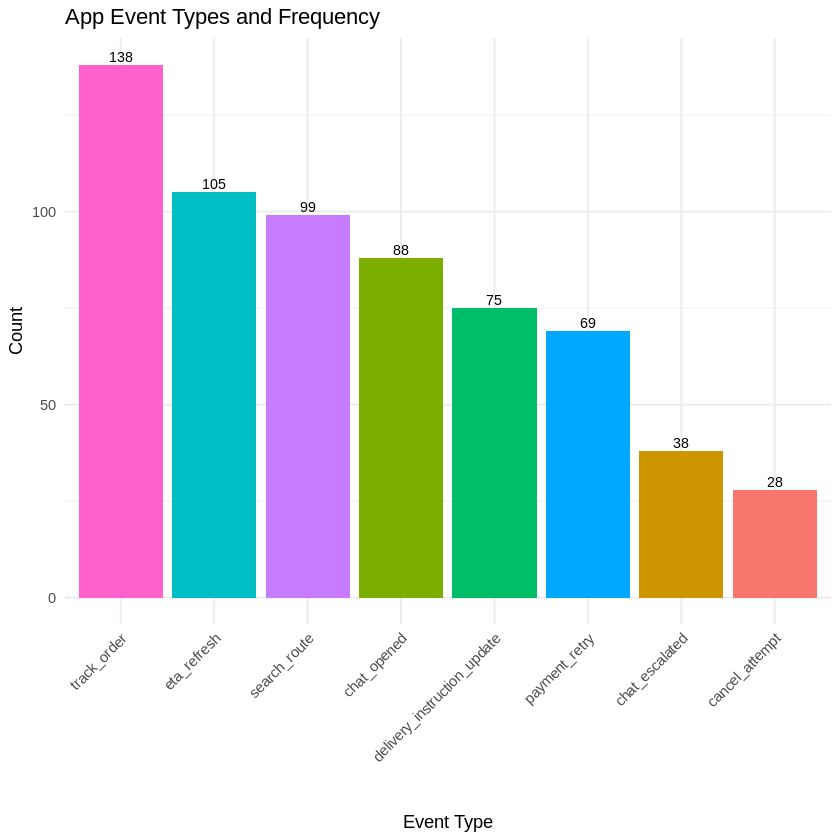

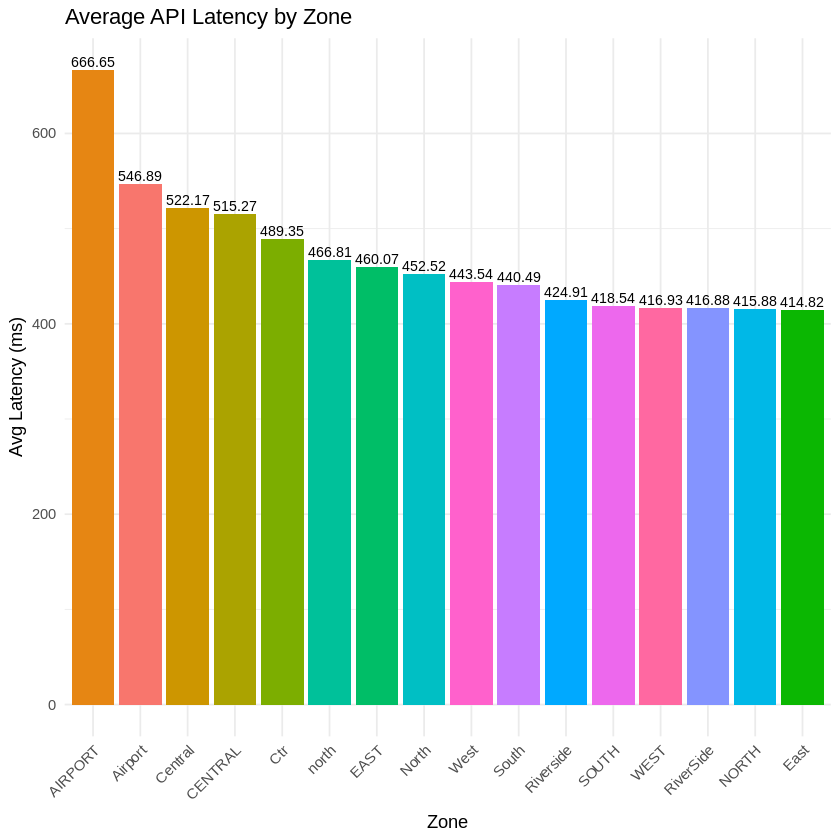

In [ ]:
q13 <- sqldf("
  SELECT ae.event_type,
         ae.device_type,
         COUNT(*) AS total_events,
         ROUND(AVG(ae.api_latency_ms),2) AS avg_latency,
         SUM(CASE WHEN ae.success_flag=0 THEN 1 ELSE 0 END) AS failed_events
  FROM app_events ae
  GROUP BY ae.event_type, ae.device_type
  ORDER BY total_events DESC
")

print(q13)

event_summary <- sqldf("
  SELECT event_type,
         COUNT(*) AS total,
         ROUND(AVG(api_latency_ms),2) AS avg_latency,
         SUM(CASE WHEN success_flag=0 THEN 1 ELSE 0 END) AS failed_events
  FROM app_events
  GROUP BY event_type
  ORDER BY total DESC
")

ggplot(event_summary,
       aes(x=reorder(event_type,-total),
           y=total, fill=event_type)) +
  geom_bar(stat="identity") +
  geom_text(aes(label=total), vjust=-0.3, size=3) +
  labs(title="App Event Types and Frequency",
       x="Event Type", y="Count") +
  theme_minimal() +
  theme(axis.text.x=element_text(angle=45, hjust=1),
        legend.position="none")

latency_zone <- sqldf("
  SELECT zone_context,
         ROUND(AVG(api_latency_ms),2) AS avg_latency,
         COUNT(*) AS total_events,
         SUM(CASE WHEN success_flag=0 THEN 1 ELSE 0 END) AS failed_events
  FROM app_events
  GROUP BY zone_context
  ORDER BY avg_latency DESC
")

print(latency_zone)

ggplot(latency_zone,
       aes(x=reorder(zone_context,-avg_latency),
           y=avg_latency, fill=zone_context)) +
  geom_bar(stat="identity") +
  geom_text(aes(label=avg_latency), vjust=-0.3, size=3) +
  labs(title="Average API Latency by Zone",
       x="Zone", y="Avg Latency (ms)") +
  theme_minimal() +
  theme(axis.text.x=element_text(angle=45, hjust=1),
        legend.position="none")

In [ ]:
final_summary <- sqldf("
  SELECT
    COUNT(*) AS total_deliveries,
    SUM(CASE WHEN delivery_status='OnTime'  THEN 1 ELSE 0 END) AS on_time,
    SUM(CASE WHEN delivery_status='Delayed' THEN 1 ELSE 0 END) AS delayed,
    SUM(CASE WHEN delivery_status='Failed'  THEN 1 ELSE 0 END) AS failed,
    ROUND(AVG(fuel_or_charge_cost),2)           AS avg_cost,
    ROUND(AVG(route_distance_km),2)             AS avg_distance,
    ROUND(AVG(customer_rating_post_delivery),2) AS avg_rating,
    ROUND(AVG(manual_route_override_count),2)   AS avg_overrides,
    SUM(proof_of_completion_missing)            AS total_proof_missing
  FROM deliveries
")

print(final_summary)

cat("\n========================================\n")
cat("   NORTHSTAR SQL ANALYSIS — KEY FINDINGS\n")
cat("========================================\n")
cat("Total deliveries:          ", final_summary$total_deliveries, "\n")
cat("OnTime rate:               ",
    round(final_summary$on_time/final_summary$total_deliveries*100,1),"%\n")
cat("Delay rate:                ",
    round(final_summary$delayed/final_summary$total_deliveries*100,1),"%\n")
cat("Failure rate:              ",
    round(final_summary$failed/final_summary$total_deliveries*100,1),"%\n")
cat("Avg fuel/charge cost:      ", final_summary$avg_cost, "\n")
cat("Avg route distance (km):   ", final_summary$avg_distance, "\n")
cat("Avg customer rating:       ", final_summary$avg_rating, "\n")
cat("Avg manual overrides:      ", final_summary$avg_overrides, "\n")
cat("Total proof missing:       ", final_summary$total_proof_missing, "\n")
cat("Total complaints:          ", nrow(complaints), "\n")
cat("Total incidents:           ", nrow(incidents), "\n")
cat("Vehicles InRepair:         ",
    nrow(vehicles[vehicles$maintenance_status=="InRepair",]), "\n")
cat("========================================\n")
cat("\nKEY CONCLUSIONS:\n")
cat("1. 35.2% of deliveries are delayed or failed\n")
cat("2. Certain hubs and zones show structural failure patterns\n")
cat("3. Low training scores linked to higher driver delays\n")
cat("4. InRepair vehicles produce more delivery failures\n")
cat("5. Consumer customers bear the highest complaint burden\n")
cat("6. App distress events confirm poor customer experience\n")
cat("7. Fragmented systems prevent integrated root cause analysis\n")
cat("========================================\n")

  total_deliveries on_time delayed failed avg_cost avg_distance avg_rating
1              950     616     202    132    12.84        13.91       3.86
  avg_overrides total_proof_missing
1          0.97                  69

   NORTHSTAR SQL ANALYSIS — KEY FINDINGS
Total deliveries:           950 
OnTime rate:                64.8 %
Delay rate:                 21.3 %
Failure rate:               13.9 %
Avg fuel/charge cost:       12.84 
Avg route distance (km):    13.91 
Avg customer rating:        3.86 
Avg manual overrides:       0.97 
Total proof missing:        69 
Total complaints:           320 
Total incidents:            280 
Vehicles InRepair:          36 

KEY CONCLUSIONS:
1. 35.2% of deliveries are delayed or failed
2. Certain hubs and zones show structural failure patterns
3. Low training scores linked to higher driver delays
4. InRepair vehicles produce more delivery failures
5. Consumer customers bear the highest complaint burden
6. App distress events confirm poor customer e